Preview of Dataset (Transposed View):

                          0         1         2         3         4
Month              Jan-2025  Jan-2025  Jan-2025  Jan-2025  Feb-2025
Region                North     South      East      West     North
Sales                 52000     45000     48000     50000     60000
Advertising_Spend      8000      7000      7500      8200      9000
Profit                12000     10000     11000     11500     15000

=== DATASET OVERVIEW ===
Shape (Rows, Columns): (24, 5)

Dataset Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24 entries, 0 to 23
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Month              24 non-null     object
 1   Region             24 non-null     object
 2   Sales              24 non-null     int64 
 3   Advertising_Spend  24 non-null     int64 
 4   Profit             24 non-null     int64 
dtypes: int64(3), object(2)
memory usage: 1.1+ KB

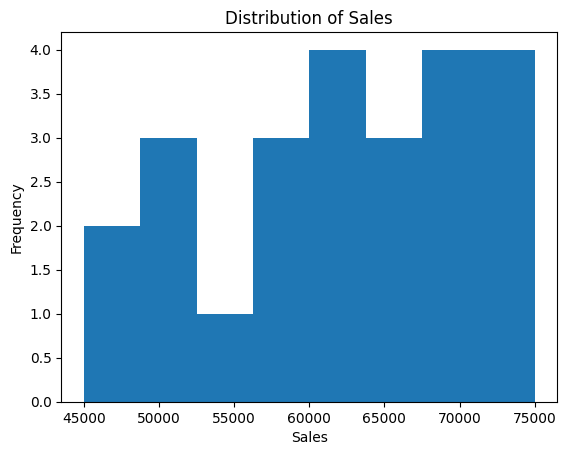

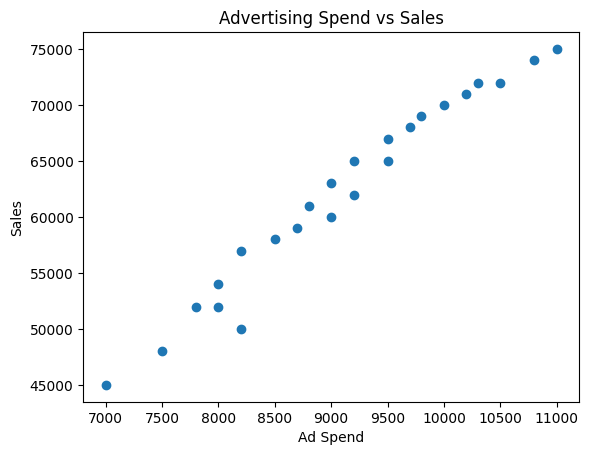

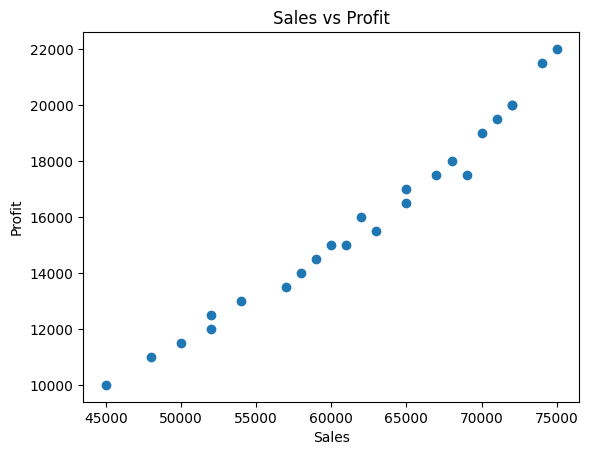

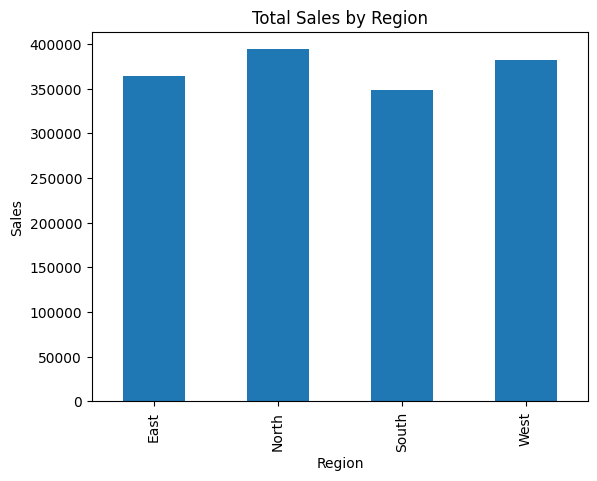

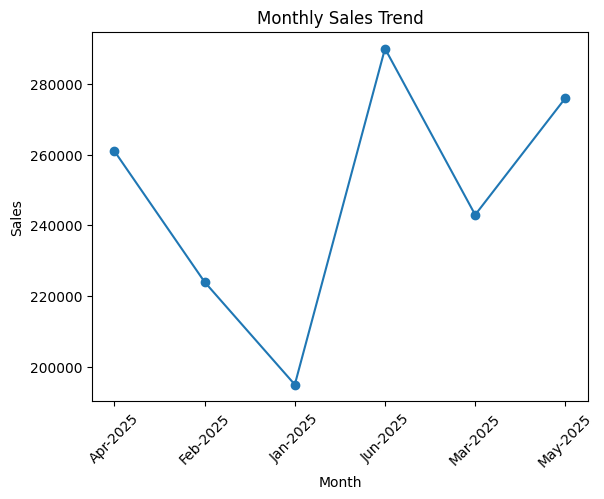


Encoded Dataset Sample:

   Month  Region  Sales  Advertising_Spend  Profit
0      2       1  52000               8000   12000
1      2       2  45000               7000   10000
2      2       0  48000               7500   11000
3      2       3  50000               8200   11500
4      1       1  60000               9000   15000

Columns used in model:
['Month', 'Region', 'Sales', 'Advertising_Spend']
Training Size: (18, 4)
Testing Size: (6, 4)

Model trained successfully.

Sample Predictions:
[11513.1485842   8743.79914974 13863.94543139 10307.59338068
 15879.03021222 18937.13005376]

Model Performance:
MSE: 511406.73081462964
R2 Score: 0.9450838409863485


In [1]:
# -------------------- STEP 1: IMPORT LIBRARIES --------------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split as split_data
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression as LR
from sklearn.metrics import mean_squared_error as mse_calc, r2_score as r2_calc


# -------------------- STEP 2: LOAD DATASET --------------------

df = pd.read_csv("Sales_Dataset_2025.csv")

print("Preview of Dataset (Transposed View):\n")
print(df.head().T)


# -------------------- STEP 3: DATA UNDERSTANDING --------------------

print("\n=== DATASET OVERVIEW ===")
print(f"Shape (Rows, Columns): {df.shape}")

print("\nDataset Info:\n")
df.info()

print("\nStatistical Summary:\n")
print(df.describe())

print("\nMissing Values:\n")
print(df.isnull().sum())


# -------------------- STEP 4: DATA VISUALIZATION --------------------

# Sales Distribution
plt.figure()
plt.hist(df["Sales"], bins=8)
plt.title("Distribution of Sales")
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.show()

# Advertising vs Sales
plt.figure()
plt.scatter(df["Advertising_Spend"], df["Sales"])
plt.title("Advertising Spend vs Sales")
plt.xlabel("Ad Spend")
plt.ylabel("Sales")
plt.show()

# Sales vs Profit
plt.figure()
plt.scatter(df["Sales"], df["Profit"])
plt.title("Sales vs Profit")
plt.xlabel("Sales")
plt.ylabel("Profit")
plt.show()

# Region-wise Sales
plt.figure()
df.groupby("Region")["Sales"].sum().plot(kind="bar")
plt.title("Total Sales by Region")
plt.xlabel("Region")
plt.ylabel("Sales")
plt.show()

# Monthly Trend
plt.figure()
df.groupby("Month")["Sales"].sum().plot(kind="line", marker="o")
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.show()


# -------------------- STEP 5: DATA PREPROCESSING --------------------

encoder = LabelEncoder()

df["Month"] = encoder.fit_transform(df["Month"])
df["Region"] = encoder.fit_transform(df["Region"])

print("\nEncoded Dataset Sample:\n")
print(df.head())


# -------------------- STEP 6: FEATURE SELECTION --------------------

features = df.drop("Profit", axis=1)
target = df["Profit"]

print("\nColumns used in model:")
print(features.columns.tolist())


# -------------------- STEP 7: TRAIN-TEST SPLIT --------------------

X_train, X_test, y_train, y_test = split_data(
    features, target, test_size=0.25, random_state=10
)

print(f"Training Size: {X_train.shape}")
print(f"Testing Size: {X_test.shape}")


# -------------------- STEP 8: MODEL TRAINING --------------------

reg_model = LR()
reg_model.fit(X_train, y_train)

print("\nModel trained successfully.")


# -------------------- STEP 9: PREDICTION --------------------

predicted_profit = reg_model.predict(X_test)

print("\nSample Predictions:")
print(predicted_profit[:10])


# -------------------- STEP 10: MODEL EVALUATION --------------------

error_value = mse_calc(y_test, predicted_profit)
score_value = r2_calc(y_test, predicted_profit)

print("\nModel Performance:")
print(f"MSE: {error_value}")
print(f"R2 Score: {score_value}")